# Validation de robustesse du clustering (Classification Ascendante Hiérarchique)

> **Renommé** depuis `Test_overfittinng.ipynb` : ce fichier n'est pas un test automatisé
> (pas de `pytest`, pas d'`assert`) mais un notebook de diagnostic exploratoire — le préfixe
> `Test_` prêtait à confusion. Suggestion de rangement : un dossier `notebooks/` séparé de
> `src/` (qui ne contiendrait alors que des modules `.py` importables).

**Mise à jour méthodologique** : ce notebook testait initialement le K-Means, mais le modèle
retenu en production (cf. `outputs/comparison_results.json`, `best_model: "Hierarchical"`) est la
**Classification Ascendante Hiérarchique (CAH, linkage="ward", k=3)**. Les 5 diagnostics ont donc
été relancés sur la CAH, le modèle réellement livré, plutôt que sur le K-Means écarté.

**Objectif** : vérifier que le clustering retenu (CAH, k=3, cf. `common.FORCED_K`) reflète
une vraie structure dans les données, et non un artefact de sur-ajustement à cet échantillon
précis. Cinq diagnostics indépendants sont menés :

1. **Stabilité par bootstrap** — le clustering est-il identique si on ré-échantillonne les retailers ?
2. **Stabilité du cluster à risque** — le segment de retailers à fort risque commercial (celui qui
   justifie de fixer k=3, cf. `decisions.FORCED_K_DECISION`) est-il stable sous ré-échantillonnage ?
3. **Sensibilité au bruit** — le clustering se dégrade-t-il progressivement (bon signe) ou
   brutalement (signe de sur-ajustement) quand on perturbe les features ?
4. **Sensibilité aux hyperparamètres** — le score de silhouette est-il stable autour de k=3 ?
   (la CAH avec linkage "ward" est déterministe — pas de graine aléatoire à faire varier,
   contrairement à K-Means ; ce diagnostic devient donc une seule évaluation par k plutôt
   qu'une moyenne sur plusieurs graines)
5. **Cohérence train/test** — un modèle entraîné sur `data_entrainement.csv` généralise-t-il à
   `data_test.csv` (jeu externe, jamais vu à l'entraînement) ? La CAH étant transductive (pas de
   `.predict()` natif), on réutilise le même classifieur surrogate `NearestCentroid` que
   `common.ClusterPredictor` utilise en production pour scorer de nouveaux retailers.

> **Prérequis** : ce notebook doit être ouvert et exécuté avec `validation/` (son propre dossier)
> comme dossier de travail. Les chemins relatifs vers `../data/` et `../outputs/figures/` restent
> valides depuis `validation/` (dossier frère de `src/`) ; l'import des modules de `src/`
> (`hiearchical_recommendation`, `common`) est géré explicitement dans la cellule suivante via
> `sys.path`, puisque ces modules ne sont plus dans le même dossier que ce notebook.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestCentroid

# Ce notebook vit dans validation/, un dossier frere de src/ : on ajoute src/ au
# chemin d'import Python pour pouvoir importer ses modules (hiearchical_recommendation, common).
SRC_DIR = (Path.cwd() / ".." / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import hiearchical_recommendation as hier_mod
from common import (
    RANDOM_STATE,
    FORCED_K,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    load_raw_data,
    build_retailer_features,
    build_retailer_game_matrix,
    identify_risk_cluster,
)

import warnings
warnings.filterwarnings("ignore", module=r"^sklearn")
warnings.filterwarnings("ignore", module=r"^scipy")

%matplotlib inline

SCRIPT_DIR = Path.cwd()
TEST_DATA_PATH = SCRIPT_DIR / ".." / "data" / "data_test.csv"
FIGURES_DIR = SCRIPT_DIR / ".." / "outputs" / "figures"

LINKAGE = "ward"
N_BOOTSTRAP = 30
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
K_CANDIDATES = range(2, 9)


## 1. Chargement des données et détermination de k

On recharge le pipeline de préparation des features (`Kmeans_recommendation.load_and_prepare` —
la préparation des features est commune à tous les modèles) et on retrouve le k retenu en
production (`FORCED_K`).


In [2]:
df_retailers, pivot, X, preprocessor = hier_mod.load_and_prepare()

k_ref = FORCED_K

print(f"k retenu pour les tests de robustesse (forcé, cf. decisions.FORCED_K_DECISION) : {k_ref}")


k retenu pour les tests de robustesse (forcé, cf. decisions.FORCED_K_DECISION) : 3


## 2. Stabilité par bootstrap (Adjusted Rand Index)

On ré-échantillonne 80% des retailers, `N_BOOTSTRAP` fois, on reclusterise à chaque tirage (CAH
ward, k=3), et on compare (via l'ARI) le clustering obtenu à celui du modèle de référence entraîné
sur l'ensemble des données. Un ARI moyen proche de 1 indique un clustering stable ; proche de 0,
un clustering instable (probable sur-ajustement).


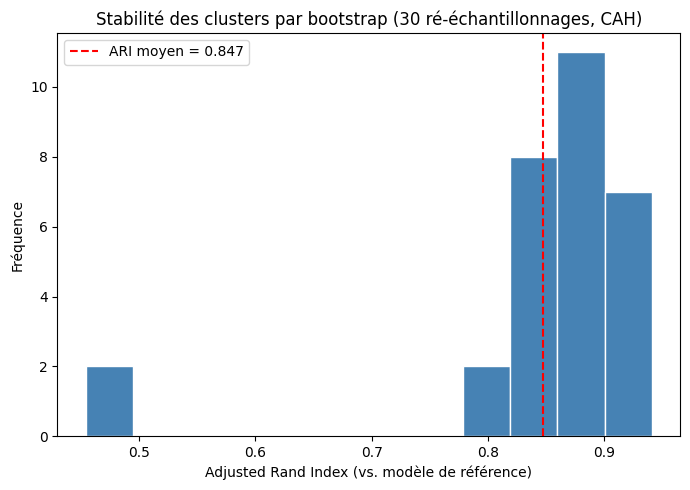

ARI moyen : 0.847 (écart-type : 0.106)


In [3]:
def bootstrap_stability(X, k, n_bootstrap=N_BOOTSTRAP, sample_frac=0.8):
    reference_labels = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X)
    n = X.shape[0]

    ari_scores = []
    rng = np.random.RandomState(RANDOM_STATE)
    for i in range(n_bootstrap):
        idx = rng.choice(n, size=int(n * sample_frac), replace=False)
        X_sample = X[idx]
        sample_labels_pred = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X_sample)
        sample_labels_ref = reference_labels[idx]
        ari_scores.append(adjusted_rand_score(sample_labels_ref, sample_labels_pred))

    return np.array(ari_scores)


def plot_bootstrap_distribution(ari_scores, out_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(ari_scores, bins=12, color="steelblue", edgecolor="white")
    ax.axvline(ari_scores.mean(), color="red", linestyle="--",
               label=f"ARI moyen = {ari_scores.mean():.3f}")
    ax.set_title(f"Stabilité des clusters par bootstrap ({N_BOOTSTRAP} ré-échantillonnages, CAH)")
    ax.set_xlabel("Adjusted Rand Index (vs. modèle de référence)")
    ax.set_ylabel("Fréquence")
    ax.legend()
    plt.tight_layout()
    os.makedirs(out_path.parent, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


ari_scores = bootstrap_stability(X, k_ref)
plot_bootstrap_distribution(ari_scores, FIGURES_DIR / "bootstrap_stability_cah.png")
print(f"ARI moyen : {ari_scores.mean():.3f} (écart-type : {ari_scores.std():.3f})")


## 3. Stabilité du cluster à risque (indice de Jaccard)

Le segment de retailers à très fort risque commercial (taux de forclusion/annulation élevés) est
la justification métier de forcer k=3 (cf. `decisions.FORCED_K_DECISION`). On vérifie ici que ce
cluster précis reste identifiable et stable sous ré-échantillonnage, via l'indice de Jaccard entre
le cluster de référence et son équivalent retrouvé dans chaque échantillon bootstrap.


cluster à risque identifié : 2 (36 retailers)


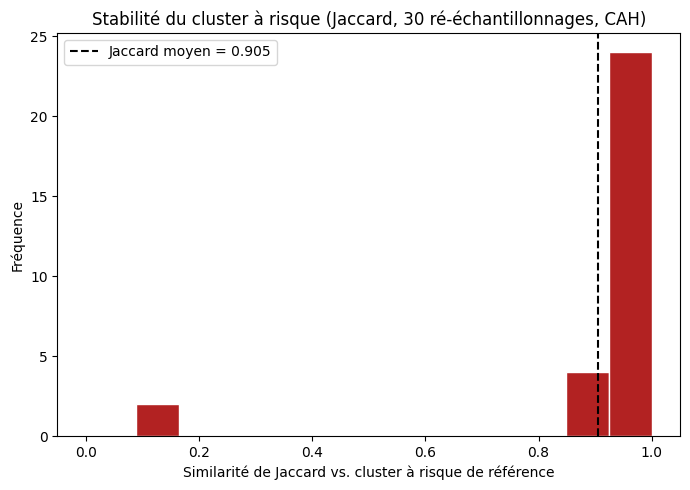

Jaccard moyen : 0.905 (écart-type : 0.220, échantillons sans membre du cluster à risque : 0/30)


In [4]:
def risk_cluster_stability(X, k, reference_labels, risk_cluster_id,
                            n_bootstrap=N_BOOTSTRAP, sample_frac=0.8):
    reference_risk_members = set(np.where(reference_labels == risk_cluster_id)[0])
    n = X.shape[0]

    rng = np.random.RandomState(RANDOM_STATE)
    jaccard_scores = []
    no_match_count = 0

    for i in range(n_bootstrap):
        idx = rng.choice(n, size=int(n * sample_frac), replace=False)
        X_sample = X[idx]
        sample_labels = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X_sample)

        ref_risk_positions_in_sample = [
            pos for pos, original_idx in enumerate(idx) if original_idx in reference_risk_members
        ]

        if not ref_risk_positions_in_sample:
            jaccard_scores.append(np.nan)
            no_match_count += 1
            continue

        candidate_labels = sample_labels[ref_risk_positions_in_sample]
        matched_cluster = np.bincount(candidate_labels).argmax()

        predicted_members = set(np.where(sample_labels == matched_cluster)[0])
        reference_members = set(ref_risk_positions_in_sample)

        intersection = predicted_members & reference_members
        union = predicted_members | reference_members
        jaccard_scores.append(len(intersection) / len(union) if union else np.nan)

    return np.array(jaccard_scores), no_match_count


def plot_risk_cluster_stability(jaccard_scores, out_path):
    valid = jaccard_scores[~np.isnan(jaccard_scores)]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(valid, bins=12, color="firebrick", edgecolor="white")
    if valid.size:
        ax.axvline(valid.mean(), color="black", linestyle="--",
                   label=f"Jaccard moyen = {valid.mean():.3f}")
    ax.set_title(f"Stabilité du cluster à risque (Jaccard, {N_BOOTSTRAP} ré-échantillonnages, CAH)")
    ax.set_xlabel("Similarité de Jaccard vs. cluster à risque de référence")
    ax.set_ylabel("Fréquence")
    ax.set_xlim(-0.05, 1.05)
    ax.legend()
    plt.tight_layout()
    os.makedirs(out_path.parent, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


reference_labels = AgglomerativeClustering(n_clusters=k_ref, linkage=LINKAGE).fit_predict(X)
risk_cluster_id = identify_risk_cluster(df_retailers, reference_labels)
print(f"cluster à risque identifié : {risk_cluster_id} "
      f"({(reference_labels == risk_cluster_id).sum()} retailers)")

jaccard_scores, no_match_count = risk_cluster_stability(X, k_ref, reference_labels, risk_cluster_id)
plot_risk_cluster_stability(jaccard_scores, FIGURES_DIR / "risk_cluster_stability_cah.png")
valid = jaccard_scores[~np.isnan(jaccard_scores)]
print(f"Jaccard moyen : {valid.mean():.3f} (écart-type : {valid.std():.3f}, "
      f"échantillons sans membre du cluster à risque : {no_match_count}/{N_BOOTSTRAP})")


## 4. Sensibilité au bruit

On ajoute un bruit gaussien croissant aux features, on reclusterise (CAH ward, k=3), et on mesure
l'ARI par rapport au clustering sans bruit. Une dégradation progressive et régulière est attendue
(bon signe) ; une chute brutale au moindre bruit indiquerait un clustering instable, sensible au
sur-ajustement.


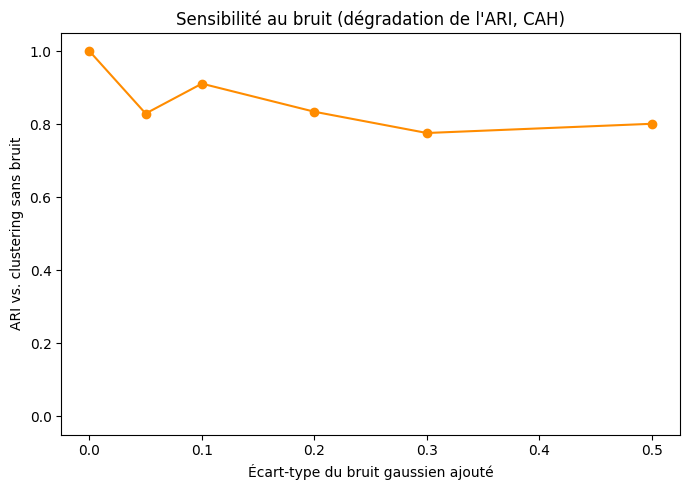

bruit std=0.00 -> ARI=1.000
bruit std=0.05 -> ARI=0.829
bruit std=0.10 -> ARI=0.911
bruit std=0.20 -> ARI=0.834
bruit std=0.30 -> ARI=0.776
bruit std=0.50 -> ARI=0.801


In [5]:
def noise_sensitivity(X, k, noise_levels=NOISE_LEVELS):
    reference_labels = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X)

    rng = np.random.RandomState(RANDOM_STATE)
    results = []
    for noise_std in noise_levels:
        noisy_X = X + rng.normal(0, noise_std, size=X.shape)
        noisy_labels = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(noisy_X)
        ari = adjusted_rand_score(reference_labels, noisy_labels)
        results.append(ari)
    return results


def plot_noise_sensitivity(noise_levels, ari_scores, out_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(noise_levels, ari_scores, "o-", color="darkorange")
    ax.set_title("Sensibilité au bruit (dégradation de l'ARI, CAH)")
    ax.set_xlabel("Écart-type du bruit gaussien ajouté")
    ax.set_ylabel("ARI vs. clustering sans bruit")
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    os.makedirs(out_path.parent, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


noise_aris = noise_sensitivity(X, k_ref)
plot_noise_sensitivity(NOISE_LEVELS, noise_aris, FIGURES_DIR / "noise_sensitivity_cah.png")
for level, ari in zip(NOISE_LEVELS, noise_aris):
    print(f"bruit std={level:.2f} -> ARI={ari:.3f}")


## 5. Sensibilité aux hyperparamètres (choix de k)

Pour chaque k candidat (2 à 8), on recalcule le score de silhouette. **Différence par rapport au
K-Means** : la CAH avec linkage "ward" n'a pas d'initialisation aléatoire (contrairement à
K-Means, qui dépend d'une graine) — pour un jeu de données donné, elle est entièrement
déterministe. Il n'y a donc rien à faire varier sur plusieurs graines ici : ce diagnostic devient
une seule évaluation par k plutôt qu'une moyenne ± écart-type sur 5 graines.


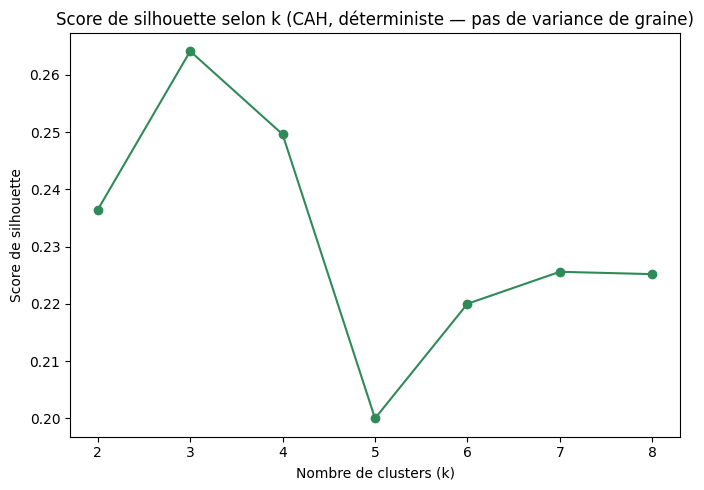

k=2 -> silhouette=0.236
k=3 -> silhouette=0.264
k=4 -> silhouette=0.250
k=5 -> silhouette=0.200
k=6 -> silhouette=0.220
k=7 -> silhouette=0.226
k=8 -> silhouette=0.225


In [6]:
def hyperparameter_sensitivity(X, k_candidates=K_CANDIDATES):
    results = {}
    for k in k_candidates:
        labels = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X)
        results[k] = silhouette_score(X, labels)
    return results


def plot_hyperparameter_sensitivity(results, out_path):
    ks = list(results.keys())
    scores = [results[k] for k in ks]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(ks, scores, "o-", color="seagreen")
    ax.set_title("Score de silhouette selon k (CAH, déterministe — pas de variance de graine)")
    ax.set_xlabel("Nombre de clusters (k)")
    ax.set_ylabel("Score de silhouette")
    plt.tight_layout()
    os.makedirs(out_path.parent, exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()


hp_results = hyperparameter_sensitivity(X)
plot_hyperparameter_sensitivity(hp_results, FIGURES_DIR / "hyperparameter_sensitivity_cah.png")
for k, score in hp_results.items():
    print(f"k={k} -> silhouette={score:.3f}")


## 6. Cohérence train/test (généralisation à un jeu externe)

Dernier test, le plus direct : un modèle entraîné sur `data_entrainement.csv` produit-il des
affectations de cluster cohérentes avec un modèle entraîné directement sur `data_test.csv`
(jeu jamais vu à l'entraînement) ? **Différence par rapport au K-Means** : la CAH est
transductive — elle n'a pas de `.predict()` natif pour scorer de nouvelles données. On réutilise
donc exactement le même mécanisme que `common.ClusterPredictor` en production : un classifieur
surrogate `NearestCentroid`, entraîné sur les points et labels d'entraînement, sert à prédire le
cluster des nouveaux retailers de test.


In [7]:
def load_external_test_set(preprocessor, test_csv_path=TEST_DATA_PATH):
    df_raw_test = load_raw_data(str(test_csv_path))
    df_test_retailers = build_retailer_features(df_raw_test)
    pivot_test = build_retailer_game_matrix(df_raw_test)

    X_test = preprocessor.transform(
        df_test_retailers[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    )
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()

    return df_test_retailers, pivot_test, X_test


def train_test_consistency(X_train, X_test, k):
    labels_train = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X_train)
    surrogate = NearestCentroid().fit(X_train, labels_train)
    labels_test_predicted = surrogate.predict(X_test)

    labels_test_direct = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X_test)

    return adjusted_rand_score(labels_test_predicted, labels_test_direct)


def full_train_test_validation(df_retailers, pivot, X, preprocessor, k):
    df_test, pivot_test, X_test = load_external_test_set(preprocessor)

    labels_train = AgglomerativeClustering(n_clusters=k, linkage=LINKAGE).fit_predict(X)
    surrogate = NearestCentroid().fit(X, labels_train)
    labels_test = surrogate.predict(X_test)

    ari = train_test_consistency(X, X_test, k)

    return {"labels_train": labels_train, "labels_test": labels_test, "ari": ari}


result = full_train_test_validation(df_retailers, pivot, X, preprocessor, k_ref)
print(f"ARI train->test (cohérence de généralisation, via surrogate NearestCentroid) : {result['ari']:.3f}")


ARI train->test (cohérence de généralisation, via surrogate NearestCentroid) : 0.592


## Synthèse

Relire les 5 scores ci-dessus (ARI bootstrap, Jaccard cluster à risque, ARI bruit, silhouette par
k, ARI train/test) pour conclure si k=3 constitue, pour la **CAH** (le modèle réellement retenu),
une structure stable et généralisable, ou si certains signaux (scores bas, forte variance)
méritent d'être documentés dans `src/decisions.py` avant validation métier.

Point à noter : l'ARI train/test (généralisation) est mesuré via un classifieur surrogate
(`NearestCentroid`) plutôt qu'un `.predict()` natif, puisque la CAH est transductive — ce chiffre
n'est donc pas directement comparable à un score obtenu avec un modèle nativement inductif
comme K-Means.
